In [2]:
import seaborn as sns
import matplotlib.pyplot as plt 
from datetime import datetime 
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
import pickle 
import numpy as np
pd.set_option('future.no_silent_downcasting', True)

with open("../best_model.pkl", "rb") as file:
    gbc = pickle.load(file)

def predict_team_game(team, opponent, opp_rank, location):
    matchups = pd.read_csv("../backend/data/matchups.csv")
    team_ = matchups[matchups.Team == team]
    opponent_ = matchups[matchups.Team == opponent]
    team_stats = team_[[i for i in team_.columns if 'opp' not in i or i == "opp_margin_before"]]
    opponent_stats = opponent_[[i for i in opponent_.columns if 'opp' not in i]]

    if not len(team_stats):
        return None 

    team_stats_clean = team_stats.iloc[-1]

    if not len(opponent_stats):
        return None
    
    opponent_stats_clean = opponent_stats.iloc[-1]

    # Rename Iowa's stats to opponent columns
    opponent_as_opp = opponent_stats_clean.copy()
    opponent_as_opp.index = ["opp_" + col for col in opponent_as_opp.index]

    # Combine MSU features + opponent features
    feature_row = pd.concat([team_stats_clean, opponent_as_opp], axis=0)

    # Convert to 1-row DF for model prediction
    feature_row = feature_row.to_frame().T

    drop_cols = [
        "opp_Unnamed: 0", "opp_GameID", "Unnamed: 0","GameID","Team","opp_Team","Date", "opp_Date",
        "team_game_number","opp_team_game_number",
        "win", "loss", "Rank", "opp_Rank", "opp_win", "opp_loss",
        "opp_Location","opp_SOS_composite","opp_SOS_margin",
        "opp_SOS_winpct",
        "opp_team_is_higher_ranked",
        "opp_team_is_ranked" # target kept separately
    ]

    # Drop current-game boxscore stats
    game_stats = ["PTS","TRB","ORB","DRB","AST","STL","BLK","TOV",
                "FGA","FG","2P","2PA","3P","3PA","FT","FTA","PF", "Poss", "ORtg", "DRtg", "NetRtg"]

    drop_cols += game_stats
    drop_cols += [f"opp_{c}" for c in game_stats]

    feature_row = feature_row.drop(drop_cols, axis=1).rename(columns = {"opp_avg_DRtg" : "avg_opp_DRtg", "opp_avg_NetRtg" : "avg_opp_NetRtg", "opp_avg_ORtg" : "avg_opp_ORtg"})

    feature_row["opp_is_ranked"] = (True if opp_rank else False)
    feature_row["Location"] = (True if location == "Home" else False)

    nan_cols = feature_row.columns[feature_row.isna().any()].tolist()
    if nan_cols:
        feature_row[nan_cols] = feature_row[nan_cols].fillna(0)

    return gbc.predict_proba(feature_row[gbc.feature_names_in_])[:, 1]

def get_team_predicted_schedule(team, games):
    predicted_schedule = {}
    opponents = []
    locations = []
    probs = []
    for game in games:
        opponent, rank, location = game
        prob = predict_team_game(team, opponent, rank, location)
        if prob is None:
            continue
        opponents.append(opponent)
        probs.append(prob)
        locations.append(location)
    
    if not len(opponents):
        return None 
    
    predicted_schedule["Opponent"] = opponents
    predicted_schedule["Win Probability"] = probs
    predicted_schedule["Location"] = locations
    return pd.DataFrame(predicted_schedule)

schedule = pd.read_csv("../backend/data/schedule.csv")
schedule["Date"] = pd.to_datetime(schedule["Date"])
today = pd.Timestamp.today().normalize()
remaining_schedule = schedule[schedule["Date"] >= today]

remaining_schedule
predicted_schedules = {}
unique_teams = remaining_schedule["Team"].unique()

for team in unique_teams:
    print(f"Getting {team}'s schedule...")
    team_schedule = remaining_schedule[remaining_schedule.Team == team]
    games = [(row.iloc[0], int(row.iloc[1].strip()) if row.iloc[1].strip().isdigit() else None, row.iloc[2]) for _, row in team_schedule[["Opponent", "Opponent Rank", "Location"]].iterrows()]
    predicted_schedule = get_team_predicted_schedule(team, games)
    if predicted_schedule is None:
        print(f"Unable to get predicted schedule for {team}")
        continue
    predicted_schedules[team] = predicted_schedule
    print(f"Done with team {list(unique_teams).index(team)+1}/{len(unique_teams)}")

Getting Abilene Christian's schedule...
Done with team 1/446
Getting BYU's schedule...
Done with team 2/446
Getting Cal Poly's schedule...
Done with team 3/446
Getting UCLA's schedule...
Done with team 4/446
Getting Mount St. Mary's's schedule...
Done with team 5/446
Getting Drexel's schedule...
Done with team 6/446
Getting Mississippi Valley State's schedule...
Done with team 7/446
Getting Florida State's schedule...
Done with team 8/446
Getting Seton Hall's schedule...
Done with team 9/446
Getting Providence's schedule...
Done with team 10/446
Getting Notre Dame (MD)'s schedule...
Done with team 11/446
Getting Towson's schedule...
Done with team 12/446
Getting Alcorn State's schedule...
Done with team 13/446
Getting Baylor's schedule...
Done with team 14/446
Getting Villanova's schedule...
Done with team 15/446
Getting Wisconsin's schedule...
Done with team 16/446
Getting Morgan State's schedule...
Done with team 17/446
Getting California's schedule...
Done with team 18/446
Getting W

Iowa State Predicted Schedule: (26 - 5)


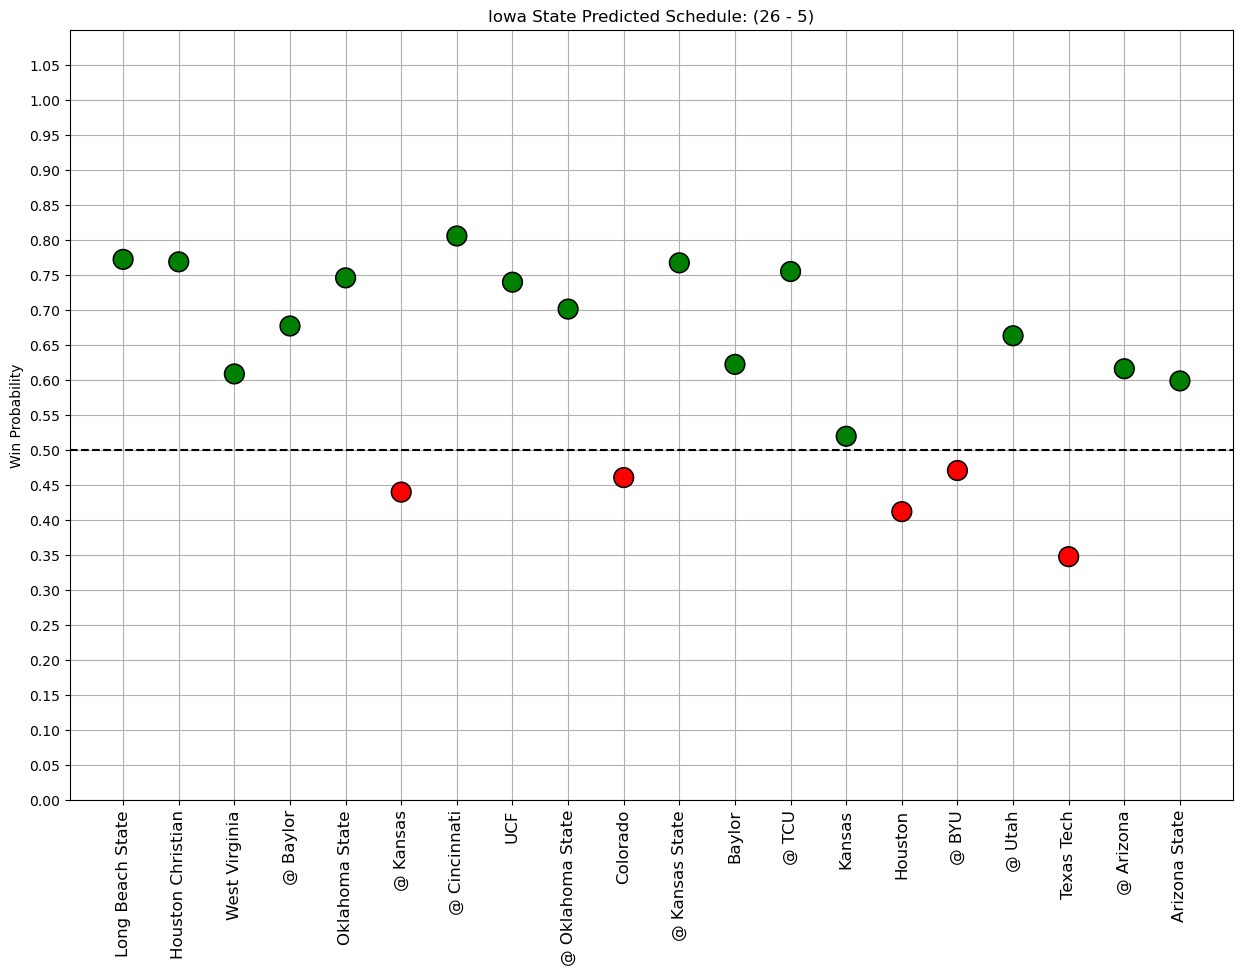

In [10]:
past_games = pd.read_csv("../backend/data/teams.csv")

def get_conference_plots(conference_teams):
    for team in conference_teams:
        predicted_schedule = predicted_schedules[team]

        # --- FIX 1: convert win probability arrays → scalars ---
        predicted_schedule["Win Probability"] = predicted_schedule["Win Probability"].apply(
            lambda x: float(x.item()) if hasattr(x, "item") else float(x)
        )

        fig, ax = plt.subplots(1, 1, figsize=(15, 10))

        # Colors for points
        colors = ["green" if p > 0.5 else "red" for p in predicted_schedule["Win Probability"]]

        # --- FIX 2: opponent label extraction ---
        opponent = [
            f"@ {row['Opponent']}" if row["Location"] == "Away" else f"{row['Opponent']}"
            for _, row in predicted_schedule.iterrows()
        ]

        sns.scatterplot(
            data=predicted_schedule,
            x=opponent,
            y="Win Probability",
            c=colors,
            legend=False,
            s=200,
            ec="black",
            ax=ax,
            zorder=20
        )

        plt.axhline(y=0.5, ls="dashed", color="black")

        past_wins = len(past_games[past_games.Team.eq(team) & past_games.Result.eq("W")])
        past_losses = len(past_games[past_games.Team.eq(team) & past_games.Result.eq("L")])

        # --- FIX 3: f-string nested quote issue ---
        wins = (predicted_schedule["Win Probability"] >= 0.5).sum()
        losses = (predicted_schedule["Win Probability"] < 0.5).sum()

        plt.title(f"{team} Predicted Schedule: ({past_wins + wins} - {past_losses + losses})")

        plt.xticks(rotation=90, fontsize=12)
        plt.yticks(ticks=np.arange(0, 1.1, 0.05))
        plt.ylim((0, 1.1))
        plt.grid()

        print(f"{team} Predicted Schedule: ({past_wins + wins} - {past_losses + losses})")

big10_teams = [
    "Iowa State"
]

get_conference_plots(big10_teams)